# CAFE: Generalizable Facial Expression Recognition
### Full Training + Evaluation Notebook
Based on ECCV 2024 — Zhang et al.

**Pipeline:**
```
Input image
  ├── CLIP (frozen) ──────────────────── image_features (512)
  └── ResNet-18 (trained) → sigmoid ──── mask
                                    ↓
                    image_features × sigmoid(x)  = masked features
                                    ↓
              channel separation (7 groups) + channel diverse loss
                                    ↓
                    loss = l_cls + 1.5×l_sep + 5×l_div
```

## 1. Install Dependencies

In [1]:
!pip install ftfy regex tqdm kagglehub
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-isokge1l
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-isokge1l
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=66ef8cdf6f1152f506fa05ea02aa814d29081308b93ff3c69633341e8cffdde0
  Stored in directory: /tmp/pip-ephem-wheel-cache-65hrryrl/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


## 2. Mount Google Drive

( make a folder in drive "deeplearning" and upload the .pth and .json filess )

.pth file --> prelearned weight from resnet for our cnn backbone

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Your Drive folder path ───────────────────────────────────────────
DRIVE_FOLDER = '/content/drive/MyDrive/deeplearning'
# ────────────────────────────────────────────────────────────────────

print('Files in your deeplearning folder:')
for f in os.listdir(DRIVE_FOLDER):
    print(' ', f)

Mounted at /content/drive
Files in your deeplearning folder:
  kaggle.json
  resnet18_msceleb.pth


## 3. Set File Paths from Drive

In [76]:
import os
import kagglehub

# ── ResNet-18 MS-Celeb weights (from Drive) ──────────────────────────
MSCELEB_PATH = os.path.join(DRIVE_FOLDER, 'resnet18_msceleb.pth')

# ── Copy kaggle.json from Drive ──────────────────────────────────────
!mkdir -p ~/.kaggle
!cp "{DRIVE_FOLDER}/kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# ── Download dataset from Kaggle ─────────────────────────────────────

# RAF-DB ___________________________________________________________________________________ UNCOMMENT for RAF-DB
dataset_path = kagglehub.dataset_download("shuvoalok/raf-db-dataset")

# FERPlus ___________________________________________________________________________________ UNCOMMENT for FERplus
#dataset_path = kagglehub.dataset_download("arnabkumarroy02/ferplus")

# ────────────────────────────────────────────────────────────────────

print('MS-Celeb weights found :', os.path.exists(MSCELEB_PATH))
print('Dataset path           :', dataset_path)

# See what's inside
print('\nDataset contents:')
for f in os.listdir(dataset_path):
    print(' ', f)

Using Colab cache for faster access to the 'raf-db-dataset' dataset.
MS-Celeb weights found : True
Dataset path           : /kaggle/input/raf-db-dataset

Dataset contents:
  test_labels.csv
  DATASET
  train_labels.csv


## 4. Explore Dataset Structure

In [77]:
import os

print('Dataset contents:')
for item in os.listdir(dataset_path):
    print(' ', item)

Dataset contents:
  test_labels.csv
  DATASET
  train_labels.csv


In [78]:
import os

# Find actual structure
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    if level < 3:  # only show 3 levels deep
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')

raf-db-dataset/
  DATASET/
    test/
    train/


Classes found: ['1', '2', '3', '4', '5', '6', '7']


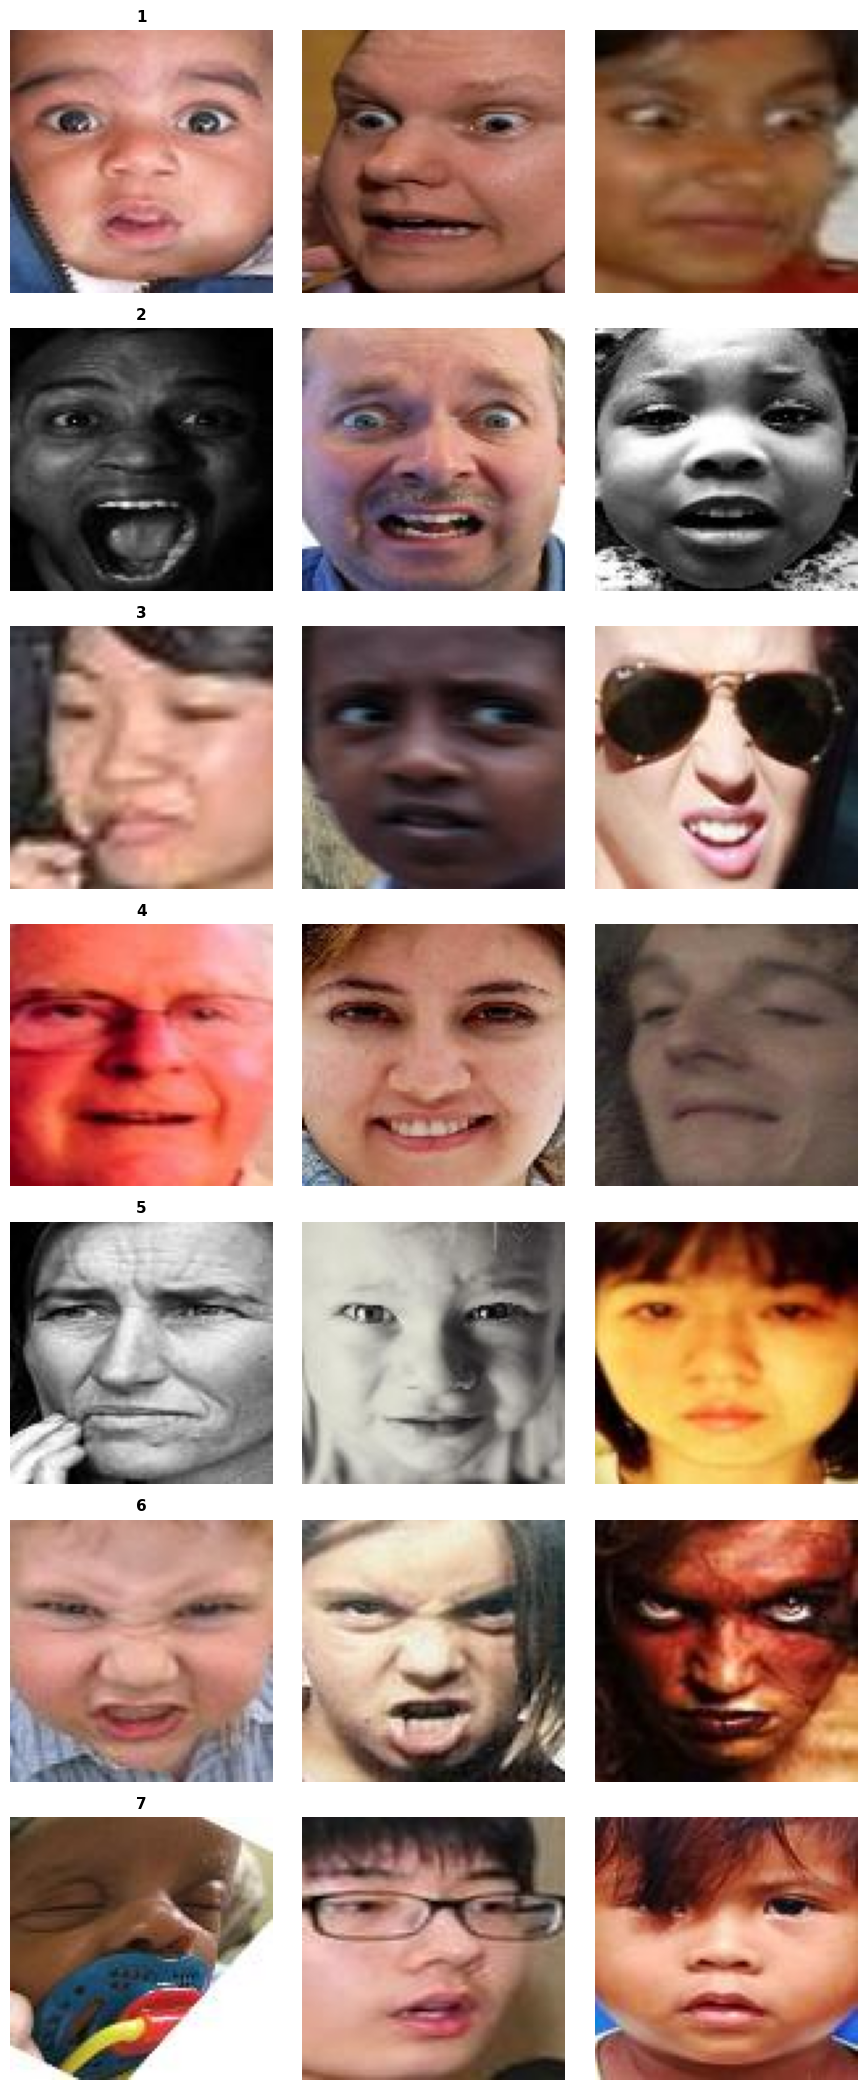

In [79]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# ── Adjust split name based on your dataset ──
# RAF-DB uses 'train' / 'test'
# FERPlus uses 'train' / 'test' / 'validation'

#RAF-DB
train_dir = os.path.join(dataset_path,'DATASET', 'train') #___________________________________________________________________________________ UNCOMMENT for RAF-DB

#FERPLUS
#train_dir = os.path.join(dataset_path,'train') #___________________________________________________________________________________ UNCOMMENT for FERplus

classes = sorted([c for c in os.listdir(train_dir) if c != 'contempt']) #exclude 'contempt' class for ferplus to make it 7 classes
print('Classes found:', classes)

# Sample images
fig, axes = plt.subplots(len(classes), 3, figsize=(9, 3 * len(classes)))
for row, emotion in enumerate(classes):
    emotion_path = os.path.join(train_dir, emotion)
    imgs = random.sample(os.listdir(emotion_path), min(3, len(os.listdir(emotion_path))))
    for col, img_file in enumerate(imgs):
        img = Image.open(os.path.join(emotion_path, img_file))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(emotion, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Imports

In [81]:
import os
import cv2
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
from torchvision import transforms
from torch.autograd import Variable
from torch.nn.modules.module import Module
from torch.nn.modules.utils import _pair
from torch.nn.parameter import Parameter

import clip
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load CLIP model (frozen)
clip_model, preprocess = clip.load("ViT-B/32", device=device)
print('CLIP loaded.')

Device: cuda:0
CLIP loaded.


## 6. Dataset Loader
Switch between RAF-DB and FERPlus by commenting/uncommenting.

In [83]:
# ── DATASET PATHS — switch by commenting/uncommenting ───────────────

# RAF-DB #___________________________________________________________________________________ UNCOMMENT for RAF-DB
DATASET_PATH = os.path.join(dataset_path, 'DATASET')
DATASET_NAME = 'RAFDB'

# FERPlus #___________________________________________________________________________________ UNCOMMENT for FERplus
#DATASET_PATH = dataset_path
#DATASET_NAME = 'FERPlus'

# ────────────────────────────────────────────────────────────────────

# Class names — same for both datasets (7 basic expressions)
# RAF-DB label order (1-indexed in txt, we subtract 1):
# 1=Surprise, 2=Fear, 3=Disgust, 4=Happy, 5=Sad, 6=Angry, 7=Neutral
CLASS_NAMES = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
NUM_CLASSES = 7

print(f'Using dataset: {DATASET_NAME}')
print(f'Path: {DATASET_PATH}')

Using dataset: RAFDB
Path: /kaggle/input/raf-db-dataset/DATASET


In [84]:
def add_g(image_array, mean=0.0, var=30):
    """Add Gaussian noise"""
    std = var ** 0.5
    image_add = image_array + np.random.normal(mean, std, image_array.shape)
    image_add = np.clip(image_add, 0, 255).astype(np.uint8)
    return image_add

def flip_image(image_array):
    return cv2.flip(image_array, 1)

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True


class FolderDataset(data.Dataset):

    def __init__(self, root, phase='train', transform=None):
        self.transform = transform
        self.aug_func  = [flip_image, add_g]
        self.phase     = phase

        split_dir = os.path.join(root, phase)
        self.classes = sorted([c for c in os.listdir(split_dir) if c != 'contempt'])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.file_paths = []
        self.labels     = []

        for cls in self.classes:
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.file_paths.append(os.path.join(cls_dir, fname))
                    self.labels.append(self.class_to_idx[cls])

        print(f'[{phase}] {len(self.file_paths)} samples | classes: {self.classes}')

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        label = self.labels[idx]
        image = cv2.imread(self.file_paths[idx])
        image = image[:, :, ::-1]  # BGR → RGB

        # Augmentation during training
        if self.phase == 'train':
            if random.uniform(0, 1) > 0.5:
                image = add_g(image)

        if self.transform is not None:
            image = self.transform(image)

        # Flipped image (used by some loss variants)
        image_flip = transforms.RandomHorizontalFlip(p=1)(image)

        return image, label, idx, image_flip

In [86]:
# Transforms — from original CAFE code
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomErasing(scale=(0.02, 0.25))
])

eval_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Dataset and Loaders ──────────────────────────────────────────────
BATCH_SIZE = 32
NUM_WORKERS = 4

train_dataset = FolderDataset(DATASET_PATH, phase='train', transform=train_transforms)
test_dataset  = FolderDataset(DATASET_PATH, phase='test',  transform=eval_transforms)

train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                               shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = data.DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

[train] 12271 samples | classes: ['1', '2', '3', '4', '5', '6', '7']
[test] 3068 samples | classes: ['1', '2', '3', '4', '5', '6', '7']
Train batches: 384 | Test batches: 96


## 7. CAFE Model Architecture
Exact code from `ours_CAFE.py`

In [87]:
# ── Custom MaxPool2d (used in channel separation) ────────────────────
class my_MaxPool2d(Module):
    def __init__(self, kernel_size, stride=None, padding=0, dilation=1,
                 return_indices=False, ceil_mode=False):
        super(my_MaxPool2d, self).__init__()
        self.kernel_size    = kernel_size
        self.stride         = stride or kernel_size
        self.padding        = padding
        self.dilation       = dilation
        self.return_indices = return_indices
        self.ceil_mode      = ceil_mode

    def forward(self, input):
        input = input.transpose(3, 1)
        input = F.max_pool2d(input, self.kernel_size, self.stride,
                             self.padding, self.dilation, self.ceil_mode,
                             self.return_indices)
        input = input.transpose(3, 1).contiguous()
        return input


# ── Channel dropping mask ────────────────────────────────────────────
def Mask(nb_batch):
    """
    Generates random channel drop mask.
    7 expression groups × (63 or 64 channels each) = 512 total
    Drops 10 channels per group randomly.
    """
    bar = []
    for i in range(7):
        foo = [1] * 63 + [0] * 10
        if i == 6:
            foo = [1] * 64 + [0] * 10  # last group gets 1 extra channel
        random.shuffle(foo)
        bar += foo
    bar = [bar for _ in range(nb_batch)]
    bar = np.array(bar).astype('float32')
    bar = bar.reshape(nb_batch, 512, 1, 1)
    bar = torch.from_numpy(bar).to(device)
    bar = Variable(bar)
    return bar


# ── Channel separation + channel diverse loss ────────────────────────
def supervisor(x, targets, cnum=73):
    """
    Computes l_sep (channel separation loss) and l_div (channel diverse loss).

    x       : masked features (N, 512)
    targets : expression labels (N,)
    cnum    : channels per expression group (73 for groups 0-5, 74 for group 6)

    Returns: [l_sep, l_div]
    """
    # l_div — channel diverse loss
    branch = x
    branch = branch.reshape(branch.size(0), branch.size(1), 1, 1)
    branch = my_MaxPool2d(kernel_size=(1, cnum), stride=(1, cnum))(branch)
    branch = branch.reshape(branch.size(0), branch.size(1),
                            branch.size(2) * branch.size(3))
    loss_2 = 1.0 - 1.0 * torch.mean(torch.sum(branch, 2)) / cnum

    # l_sep — channel separation cross-entropy loss
    mask    = Mask(x.size(0))
    branch_1 = x.reshape(x.size(0), x.size(1), 1, 1) * mask
    branch_1 = my_MaxPool2d(kernel_size=(1, cnum), stride=(1, cnum))(branch_1)
    branch_1 = branch_1.view(branch_1.size(0), -1)
    loss_1   = nn.CrossEntropyLoss()(branch_1, targets)

    return [loss_1, loss_2]


# ── Custom ResNet-18 BasicBlock ──────────────────────────────────────
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        if downsample:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.downsample = None

    def forward(self, x):
        i = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        if self.downsample is not None:
            i = self.downsample(i)
        x += i
        return self.relu(x)


# ── Custom ResNet ────────────────────────────────────────────────────
class ResNet(nn.Module):
    def __init__(self, block, n_blocks, channels, output_dim):
        super().__init__()
        self.in_channels = channels[0]
        assert len(n_blocks) == len(channels) == 4

        self.conv1   = nn.Conv2d(3, self.in_channels, kernel_size=7,
                                  stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(self.in_channels)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1  = self.get_resnet_layer(block, n_blocks[0], channels[0])
        self.layer2  = self.get_resnet_layer(block, n_blocks[1], channels[1], stride=2)
        self.layer3  = self.get_resnet_layer(block, n_blocks[2], channels[2], stride=2)
        self.layer4  = self.get_resnet_layer(block, n_blocks[3], channels[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(self.in_channels, output_dim)

    def get_resnet_layer(self, block, n_blocks, channels, stride=1):
        layers = []
        downsample = (self.in_channels != block.expansion * channels)
        layers.append(block(self.in_channels, channels, stride, downsample))
        for _ in range(1, n_blocks):
            layers.append(block(block.expansion * channels, channels))
        self.in_channels = block.expansion * channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.fc(h)
        return x, h


# ── CAFE Main Model ──────────────────────────────────────────────────
class Model(nn.Module):
    """
    CAFE model — exact implementation from ours_CAFE.py

    Forward (train): returns (logits, [l_sep, l_div])
    Forward (test) : returns (logits, logits)

    Loss = l_cls + 1.5 * l_sep + 5 * l_div
    """
    def __init__(self, msceleb_path, num_classes=7, drop_rate=0):
        super(Model, self).__init__()

        # Build ResNet-18 and load MS-Celeb weights
        res18 = ResNet(block=BasicBlock, n_blocks=[2, 2, 2, 2],
                       channels=[64, 128, 256, 512], output_dim=1000)
        msceleb_model = torch.load(msceleb_path, map_location='cpu')
        state_dict    = msceleb_model['state_dict']
        res18.load_state_dict(state_dict, strict=False)
        print('MS-Celeb weights loaded.')

        self.drop_rate = drop_rate
        self.features  = nn.Sequential(*list(res18.children())[:-2])   # conv layers
        self.features2 = nn.Sequential(*list(res18.children())[-2:-1]) # avgpool

        fc_in_dim = list(res18.children())[-1].in_features  # 512
        self.fc   = nn.Linear(fc_in_dim, num_classes)        # 512 → 7

        self.parm = {}
        for name, parameters in self.fc.named_parameters():
            print(name, ':', parameters.size())
            self.parm[name] = parameters

    def forward(self, x, clip_model, targets, phase='train'):
        # CLIP features — frozen, no grad
        with torch.no_grad():
            image_features = clip_model.encode_image(x)
            image_features = image_features.float()  # ensure float32

        # ResNet-18 features
        x  = self.features(x)       # (N, 512, 7, 7)
        x  = self.features2(x)      # (N, 512, 1, 1)
        x  = x.view(x.size(0), -1)  # (N, 512)

        # Sigmoid mask + CLIP feature selection
        if phase == 'train':
            MC_loss = supervisor(image_features * torch.sigmoid(x),
                                 targets, cnum=73)

        x   = image_features * torch.sigmoid(x)  # (N, 512) masked features
        out = self.fc(x)                           # (N, 7) logits

        if phase == 'train':
            return out, MC_loss
        else:
            return out, out


print('Model architecture defined.')

Model architecture defined.


## 8. Initialize Model, Optimizer, Scheduler

In [88]:
setup_seed(3407)

model = Model(msceleb_path=MSCELEB_PATH, num_classes=NUM_CLASSES)
model.to(device)

# From original CAFE code
optimizer = torch.optim.Adam(model.parameters(), lr=0.0002, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

EPOCHS = 20

print(f'\nOptimizer : Adam  lr=0.0002, wd=1e-4')
print(f'Scheduler : ExponentialLR gamma=0.9')
print(f'Epochs    : {EPOCHS}')

MS-Celeb weights loaded.
weight : torch.Size([7, 512])
bias : torch.Size([7])

Optimizer : Adam  lr=0.0002, wd=1e-4
Scheduler : ExponentialLR gamma=0.9
Epochs    : 20


## 9. Train and Test Functions

In [89]:
def train_one_epoch(model, train_loader, optimizer, scheduler, device):
    """
    One training epoch.
    loss = l_cls + 5 * l_div + 1.5 * l_sep
    """
    model.train()
    running_loss = 0.0
    iter_cnt     = 0
    correct_sum  = 0

    for imgs, labels, indexes, imgs_flip in train_loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)

        output, MC_loss = model(imgs, clip_model, labels, phase='train')

        # Total loss — from original CAFE code
        loss_cls = nn.CrossEntropyLoss()(output, labels)   # l_cls
        loss     = loss_cls + 5 * MC_loss[1] + 1.5 * MC_loss[0]  # + l_div + l_sep

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        iter_cnt += 1
        _, predicts  = torch.max(output, 1)
        correct_sum  += torch.eq(predicts, labels).sum()
        running_loss += loss

    scheduler.step()
    running_loss = running_loss / iter_cnt
    acc = correct_sum.float() / float(train_loader.dataset.__len__())
    return acc.item(), running_loss.item()


def test_model(model, test_loader, device):
    """
    Evaluation — uses only l_cls path (no separation/diverse at test time).
    """
    model.eval()
    with torch.no_grad():
        running_loss = 0.0
        iter_cnt     = 0
        correct_sum  = 0
        data_num     = 0

        for imgs, labels, indexes, imgs_flip in test_loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)

            outputs, _ = model(imgs, clip_model, labels, phase='test')
            loss       = nn.CrossEntropyLoss()(outputs, labels)

            iter_cnt  += 1
            _, predicts = torch.max(outputs, 1)
            correct_sum += torch.eq(predicts, labels).sum()
            running_loss += loss
            data_num     += outputs.size(0)

        running_loss = running_loss / iter_cnt
        test_acc     = correct_sum.float() / float(data_num)

    return test_acc.item(), running_loss.item()


print('Train and test functions ready.')

Train and test functions ready.


In [90]:
# Check GPU
!nvidia-smi

# Check batch size and how many batches per epoch
print(f'Batch size     : {BATCH_SIZE}')
print(f'Train batches  : {len(train_loader)}')
print(f'Estimated time : {len(train_loader) * 3} seconds per epoch')

Wed Apr 29 18:32:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P0             29W /   70W |    8227MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 10. Training Loop

In [91]:
history = {'train_acc': [], 'train_loss': [], 'test_acc': [], 'test_loss': []}
best_acc = 0.0

print('=' * 60)
print(f'Training CAFE on {DATASET_NAME}')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):

    train_acc, train_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, device
    )
    test_acc, test_loss = test_model(model, test_loader, device)

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['test_acc'].append(test_acc)
    history['test_loss'].append(test_loss)

    print(f'Epoch [{epoch:>3}/{EPOCHS}] '
          f'Train Acc: {train_acc*100:5.2f}% Loss: {train_loss:.4f} | '
          f'Test Acc: {test_acc*100:5.2f}% Loss: {test_loss:.4f}')

    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({'model_state_dict': model.state_dict()}, 'ours_best.pth')
        print(f'  ✓ Best model saved (acc={best_acc*100:.2f}%)')

    # Save latest
    torch.save({'model_state_dict': model.state_dict()}, 'ours_final.pth')

    # Log to file
    with open('results.txt', 'a') as f:
        f.write(f'{epoch}_{test_acc:.4f}\n')

print('=' * 60)
print(f'Training complete. Best test acc: {best_acc*100:.2f}%')

Training CAFE on RAFDB
Epoch [  1/20] Train Acc: 52.12% Loss: 9.2100 | Test Acc: 69.62% Loss: 1.0862
  ✓ Best model saved (acc=69.62%)
Epoch [  2/20] Train Acc: 69.95% Loss: 8.6567 | Test Acc: 76.96% Loss: 0.8370
  ✓ Best model saved (acc=76.96%)
Epoch [  3/20] Train Acc: 77.69% Loss: 8.4209 | Test Acc: 80.64% Loss: 0.6988
  ✓ Best model saved (acc=80.64%)
Epoch [  4/20] Train Acc: 81.97% Loss: 8.2464 | Test Acc: 83.21% Loss: 0.5986
  ✓ Best model saved (acc=83.21%)
Epoch [  5/20] Train Acc: 85.19% Loss: 8.1197 | Test Acc: 85.40% Loss: 0.5353
  ✓ Best model saved (acc=85.40%)
Epoch [  6/20] Train Acc: 87.34% Loss: 8.0322 | Test Acc: 85.95% Loss: 0.5037
  ✓ Best model saved (acc=85.95%)
Epoch [  7/20] Train Acc: 89.34% Loss: 7.9638 | Test Acc: 85.59% Loss: 0.4735
Epoch [  8/20] Train Acc: 90.88% Loss: 7.9082 | Test Acc: 87.13% Loss: 0.4478
  ✓ Best model saved (acc=87.13%)
Epoch [  9/20] Train Acc: 92.46% Loss: 7.8381 | Test Acc: 87.55% Loss: 0.4347
  ✓ Best model saved (acc=87.55%)
Epo

## 11. Training Curves

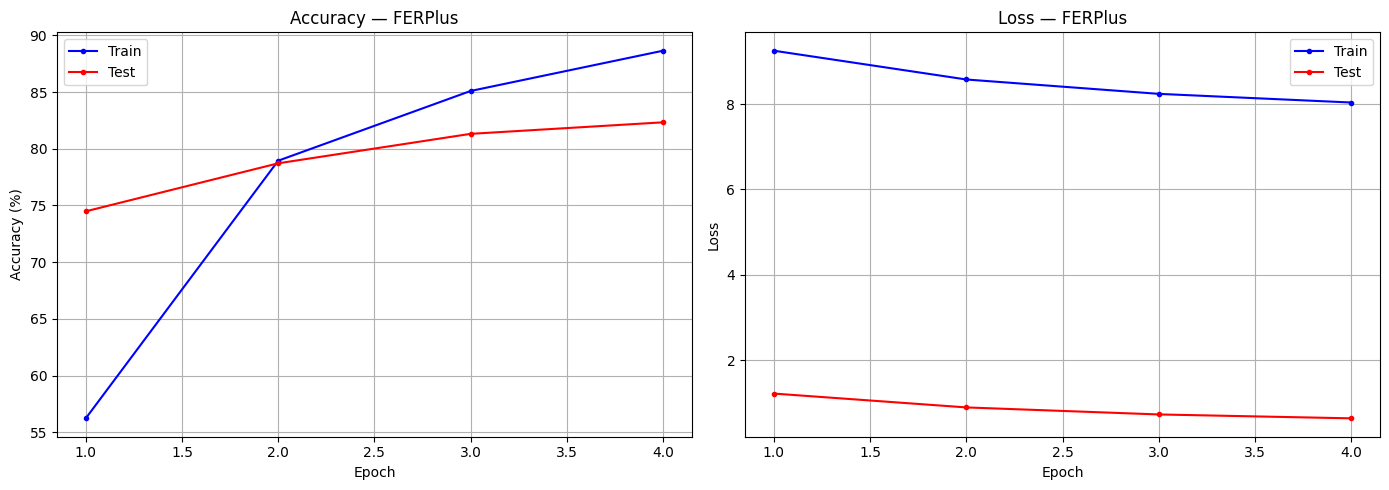

Best test accuracy: 82.33%


In [73]:
import matplotlib.pyplot as plt

epochs_x = list(range(1, len(history['train_acc']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epochs_x, [a * 100 for a in history['train_acc']], 'b-o',
             markersize=3, label='Train')
axes[0].plot(epochs_x, [a * 100 for a in history['test_acc']],  'r-o',
             markersize=3, label='Test')
axes[0].set_title(f'Accuracy — {DATASET_NAME}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs_x, history['train_loss'], 'b-o', markersize=3, label='Train')
axes[1].plot(epochs_x, history['test_loss'],  'r-o', markersize=3, label='Test')
axes[1].set_title(f'Loss — {DATASET_NAME}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('cafe_training_curves.png', dpi=150)
plt.show()
print(f'Best test accuracy: {best_acc * 100:.2f}%')

## 12. Load Best Model and Run Final Evaluation

In [74]:
# Load best checkpoint
model.load_state_dict(torch.load('ours_best.pth', map_location=device)['model_state_dict'])
print('Best model loaded.')

final_acc, final_loss = test_model(model, test_loader, device)
print(f'Final Test Accuracy : {final_acc * 100:.2f}%')
print(f'Final Test Loss     : {final_loss:.4f}')

Best model loaded.
Final Test Accuracy : 82.33%
Final Test Loss     : 0.6341


## 13. Per-Class Accuracy

In [75]:
model.eval()
class_correct = [0] * NUM_CLASSES
class_total   = [0] * NUM_CLASSES

with torch.no_grad():
    for imgs, labels, _, _ in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs, _   = model(imgs, clip_model, labels, phase='test')
        _, predicts  = torch.max(outputs, 1)
        for t, p in zip(labels, predicts):
            class_correct[t.item()] += (t == p).item()
            class_total[t.item()]   += 1

print('Per-class accuracy:')
print('-' * 30)
for i, cls in enumerate(train_dataset.classes):
    acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f'  {cls:<12} : {acc:5.2f}%  ({class_correct[i]}/{class_total[i]})')
print('-' * 30)
print(f'  {"Mean":<12} : {final_acc*100:.2f}%')

Per-class accuracy:
------------------------------
  angry        : 74.22%  (239/322)
  disgust      : 28.57%  (6/21)
  fear         : 35.71%  (35/98)
  happy        : 92.90%  (863/929)
  neutral      : 89.80%  (1144/1274)
  sad          : 59.91%  (269/449)
  suprise      : 80.22%  (361/450)
------------------------------
  Mean         : 82.33%


## 14. Sanity Check (No Data Needed)
Run this cell first to verify model forward pass works correctly.

In [29]:
print('Running sanity check...')
model.eval()

dummy_imgs   = torch.randn(4, 3, 224, 224).to(device)
dummy_labels = torch.randint(0, 7, (4,)).to(device)

# Test phase
with torch.no_grad():
    out, _ = model(dummy_imgs, clip_model, dummy_labels, phase='test')
print(f'Output shape (test) : {out.shape}  (expected: [4, 7])')

# Train phase
model.train()
out, MC_loss = model(dummy_imgs, clip_model, dummy_labels, phase='train')
l_cls = nn.CrossEntropyLoss()(out, dummy_labels)
total = l_cls + 5 * MC_loss[1] + 1.5 * MC_loss[0]

print(f'Output shape (train): {out.shape}  (expected: [4, 7])')
print(f'l_cls  : {l_cls.item():.4f}')
print(f'l_sep  : {MC_loss[0].item():.4f}')
print(f'l_div  : {MC_loss[1].item():.4f}')
print(f'total  : {total.item():.4f}')
print('\nSanity check passed! ✓')

Running sanity check...
Output shape (test) : torch.Size([4, 7])  (expected: [4, 7])
Output shape (train): torch.Size([4, 7])  (expected: [4, 7])
l_cls  : 2.1153
l_sep  : 1.9134
l_div  : 0.9918
total  : 9.9443

Sanity check passed! ✓
